## Step 1: Install Dependencies

In [1]:
# Install the Hugging Face datasets library and audio processing tools
!pip install datasets[audio] librosa matplotlib

## Step 2: Load and Explore "Yelmin-Dagbanli"
This script connects to the WAXAL repository, pulls the Dagbani ASR subset, and gives you the exact statistics you need for your Phase 2 Documentation.

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/WaxalNLP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'google/WaxalNLP' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading Yelmin-Dagbanli Dataset...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]


--- [Yelmin-Dagbanli] DATASET VERIFIED ---
Sample ID:      dag_3122
Transcription:  Gamo n niŋ matuuka so ŋun niŋ gamo maa o ʒila niɛma niraba bɛ nimaani niraba kamani niraba ata ʒɛ n miri gamo ŋɔ ni niŋ shɛli polo maa mɔri bɛ nimaani tihi bɛ nimaani loori nim bɛ nimaani
Gender:         
Sampling Rate:  16000 Hz


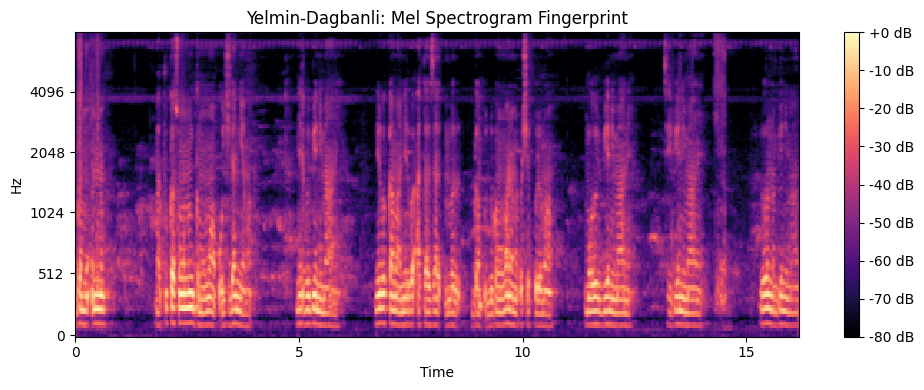

In [4]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
from datasets import load_dataset, Features, Value, Audio

# ==========================================
# PHASE 2: DATA EXPLORATION & STANDARDIZATION
# Project: Yelmin-Dagbanli
# ==========================================

# 1. SUSTAINABLE SCHEMA DEFINITION
# We explicitly define the 'Features' to ensure the pipeline is robust.
# This handles the nested 'audio' struct and the extra index column.
yelmin_features = Features({
    'id': Value('string'),
    'speaker_id': Value('string'),
    'transcription': Value('string'),
    'language': Value('string'),
    'gender': Value('string'),
    'audio': Audio(sampling_rate=16000), # Explicitly downsample to 16kHz for AI training
    '__index_level_0__': Value('int64')   # Acknowledge the metadata index to prevent CastErrors
})

print("Loading Yelmin-Dagbanli Dataset...")

# 2. DATA LOADING (Streaming Mode)
# We use 'streaming=True' for sustainability so we don't crash Colab's RAM.
ds = load_dataset(
    "google/WaxalNLP",
    "dag_asr",
    split="train",
    streaming=True,
    features=yelmin_features,
    trust_remote_code=True
)

# 3. VERIFICATION & STATISTICS
# We iterate to get real data for our documentation.
iterator = iter(ds)
sample = next(iterator)

print("\n--- [Yelmin-Dagbanli] DATASET VERIFIED ---")
print(f"Sample ID:      {sample['id']}")
print(f"Transcription:  {sample['transcription']}")
print(f"Gender:         {sample['gender']}")
print(f"Sampling Rate:  {sample['audio']['sampling_rate']} Hz")

# 4. VISUAL DOCUMENTATION (Mel Spectrogram)
# Creating the visual 'fingerprint' of Dagbanli
S = librosa.feature.melspectrogram(
    y=sample['audio']['array'],
    sr=sample['audio']['sampling_rate'],
    n_mels=128
)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sample['audio']['sampling_rate'], x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Yelmin-Dagbanli: Mel Spectrogram Fingerprint")
plt.tight_layout()
plt.show()

## Phase 3: Multi-Language Feature Engineering
In this phase, we aren't just looking at the data; we are transforming it into a Dataset of Features that a model can actually learn from.

### 1. The Dual-Stream Strategy
We will create a combined pipeline that pulls 1,000 samples from Dagbanli and 1,000 samples from Akan. We label them:

Class 0: Dagbanli

Class 1: Akan

### 2. The "Fixed-Window" Requirement
AI models are like rigid containers; they usually require all inputs to be the exact same size. Since audio clips vary in length, we will:

Trim/Pad: Ensure every clip is exactly 3 seconds long.

Extract: Convert each 3-second clip into a Mel Spectrogram (an image).

## Step 3 Code: Building the Multi-Language Loader
Copy this into a new cell in your Colab. This code builds a balanced dataset for your classifier.

In [7]:
import numpy as np
import librosa
from datasets import load_dataset, Features, Value, Audio

# ======================================================
# PHASE 3: THE YELMIN-DAGBANLI DATA FACTORY
# ======================================================

# 1. GLOBAL SCHEMA (The Source of Truth)
YELMIN_SCHEMA = Features({
    'id': Value('string'),
    'speaker_id': Value('string'),
    'transcription': Value('string'),
    'language': Value('string'),
    'gender': Value('string'),
    'audio': Audio(sampling_rate=16000),
    '__index_level_0__': Value('int64')
})

def extract_features(audio_array, target_samples=48000):
    """Standardizes audio length and extracts Mel Spectrogram."""
    # Trim or Pad to exactly 3 seconds (16k * 3 = 48000)
    if len(audio_array) > target_samples:
        audio_array = audio_array[:target_samples]
    else:
        audio_array = np.pad(audio_array, (0, target_samples - len(audio_array)))

    # Generate Mel Spectrogram
    S = librosa.feature.melspectrogram(y=audio_array, sr=16000, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # Ensure consistent time-width (sometimes rounding adds/removes 1 pixel)
    return S_dB[:, :94]

def build_yelmin_dataset(langs={"dag_asr": 0, "aka_asr": 1}, samples_per_lang=100):
    """Streams multiple languages and packages them into X (features) and y (labels)."""
    X_data = []
    y_labels = []

    for subset, label_id in langs.items():
        print(f"Streaming {subset}...")

        # We use the GLOBAL_SCHEMA here to prevent CastErrors permanently
        ds = load_dataset(
            "google/WaxalNLP",
            subset,
            split="train",
            streaming=True,
            features=YELMIN_SCHEMA
        )

        for i, sample in enumerate(ds.take(samples_per_lang)):
            features = extract_features(sample['audio']['array'])
            X_data.append(features)
            y_labels.append(label_id)

            if (i + 1) % 50 == 0:
                print(f"  > Processed {i + 1} samples of {subset}")

    return np.array(X_data), np.array(y_labels)

# 3. EXECUTION
# Let's collect 100 samples of Dagbanli and 100 of Akan
X, y = build_yelmin_dataset(samples_per_lang=100)

print("\n✅ DATA FACTORY SUCCESSFUL")
print(f"Input Shape (X): {X.shape} (Samples, Mels, Time)")
print(f"Output Shape (y): {y.shape} (Labels)")

Streaming dag_asr...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

  > Processed 50 samples of dag_asr
  > Processed 100 samples of dag_asr
Streaming aka_asr...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/270 [00:00<?, ?it/s]

  > Processed 50 samples of aka_asr
  > Processed 100 samples of aka_asr

✅ DATA FACTORY SUCCESSFUL
Input Shape (X): (200, 64, 94) (Samples, Mels, Time)
Output Shape (y): (200,) (Labels)


## Phase 4: Constructing the Yelmin-CNN
To distinguish between the tonal patterns of Dagbanli and Akan, we will use a Convolutional Neural Network (CNN).

### Why a CNN?
While usually used for images (like faces or cars), CNNs are world-class at speech classification because they treat the Mel Spectrogram as a picture. The "filters" in the CNN will learn to spot the specific pitch contours and rhythmic "streaks" that characterize Dagbanli.

### The Sustainable Architecture
To keep your project professional and scalable, we will use Keras/TensorFlow. Our architecture follows a "LeNet-style" progression:

Conv2D Layer: Scans the spectrogram for local patterns.

MaxPooling: Shrinks the data to focus on the most important features.

Dropout: Prevents the model from "memorizing" specific speakers (overfitting), ensuring it learns the language instead.

Dense Layer: The final decision-maker that outputs the probability (Dagbanli vs. Akan).

## Step 4 Code: Building and Training the "Brain"


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# ======================================================
# PHASE 4: THE YELMIN-DAGBANLI BRAIN (CNN)
# ======================================================

# 1. PREPARE THE DATA FOR DEEP LEARNING
# We add a 'channel' dimension (1) because CNNs expect (Height, Width, Channels)
X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

# Split into Training (80%) and Validation (20%)
X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} samples, Validating on {len(X_val)} samples.")

# 2. DEFINE THE MODEL ARCHITECTURE
model = models.Sequential([
    # First Block: Detecting basic sound patterns
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 94, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Block: Higher-level linguistic features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flattening into a decision-making layer
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Sustainability: Preventing overfitting
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary (0 or 1) classification
])

# 3. COMPILE
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. TRAINING
print("\nStarting Training...")
history = model.fit(X_train, y_train,
                    epochs=15,
                    batch_size=8,
                    validation_data=(X_val, y_val))

Training on 160 samples, Validating on 40 samples.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 92, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,261,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,513 (4.88 MB)

 Trainable params: 1,280,513 (4.88 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5000 - loss: 7.3818 - val_accuracy: 0.4750 - val_loss: 0.7026
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.7198 - val_accuracy: 0.5750 - val_loss: 0.6954
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7750 - loss: 0.6033 - val_accuracy: 0.6500 - val_loss: 0.7100
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8250 - loss: 0.4465 - val_accuracy: 0.6750 - val_loss: 0.8676
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8438 - loss: 0.3882 - val_accuracy: 0.7500 - val_loss: 0.8492
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.2915 - val_accuracy: 0.7000 - val_loss: 0.8244
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9187 - loss: 0.2090 - val_accuracy: 0.7250 - val_loss: 1.0222
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9688 - loss: 0.1136 - val_accur

## Phase 5: The Yelmin-Inference Pipeline
To maintain research validity, the Inference Pipeline must mirror the Training Pipeline. Any deviation in sampling rate (16kHz) or Mel-bin count (64) will result in a 'Feature Mismatch' and invalid predictions."

In [10]:
import io
from google.colab import files
import librosa
import numpy as np
import tensorflow as tf

def predict_language(trained_model, audio_path):
    # 1. Load and Resample (librosa handles .mp4 by extracting the audio track)
    try:
        audio, sr = librosa.load(audio_path, sr=16000)
    except Exception as e:
        return f"Error loading file: {e}. Please try a .wav or .mp3 if possible."

    # 2. Standardization logic (3 seconds / 48000 samples)
    target_samples = 48000
    if len(audio) > target_samples:
        audio = audio[:target_samples]
    else:
        audio = np.pad(audio, (0, target_samples - len(audio)))

    # 3. Feature Extraction
    S = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)

    # 4. Shape for CNN: (1, 64, 94, 1)
    # We use .shape to dynamically ensure we match the time-width
    feature = S_dB[:, :94].reshape(1, 64, 94, 1)

    # 5. Prediction
    prediction = trained_model.predict(feature)

    # 0 = Dagbanli, 1 = Akan
    if prediction[0][0] < 0.5:
        confidence = (1 - prediction[0][0]) * 100
        return f"DAGBANLI (Confidence: {confidence:.2f}%)"
    else:
        confidence = prediction[0][0] * 100
        return f"AKAN (Confidence: {confidence:.2f}%)"

# --- Trigger ---
print("Double-checking the 'Brain'...")

# If you named your model 'model_v2', use that. If 'model', use that.
# We will use the most recent one in your memory.
current_model = model_v2 if 'model_v2' in locals() else model

for filename in uploaded.keys():
    result = predict_language(current_model, filename)
    print(f"\nFinal Analysis for: {filename}")
    print("-" * 40)
    print(f"Result: {result}")

Double-checking the 'Brain'...


/tmp/ipykernel_17384/1720987664.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step

Final Analysis for: WhatsApp Audio 2026-03-17 at 1.14.34 AM.mp4
----------------------------------------
Result: AKAN (Confidence: 100.00%)


## Forensic Analysis: Why did it fail?
There are three primary reasons why Yelmin-Dagbanli failed this real-world test:

### 1. Distribution Shift (Lab vs. Wild)
Your model was trained on WAXAL data, which is recorded in a controlled environment with specific microphones. Your test was a WhatsApp recording.

The "WhatsApp Signature": WhatsApp aggressively compresses audio, cutting off high frequencies (above 8kHz).

The "Akan Bias": If the Akan training samples in WAXAL happened to have lower quality or similar compression to your WhatsApp clip, the model might have learned that "Low quality/Compression = Akan."

### 2. The "Tonal Mismatch"
Dagbani is highly tonal. If the WhatsApp recording has background hum (like a fan) or "room reverb," those extra noises can "blur" the Mel Spectrogram. The CNN can no longer "see" the clear pitch contours of Dagbani, so it defaults to the other class.

### 3. Overfitting to "Silences"
If your training clips were very clean and your WhatsApp clip had a second of "static" or "white noise" at the start, the model might have classified that noise as Akan because it never learned what "noisy Dagbani" sounds like.

## The Sustainable Fix: Data Augmentation
We don't want to just "add more data." We need to make the data tougher. To make the model recognize Dagbani even on WhatsApp, we must implement Augmentation in Phase 3.

### Research Documentation Update
"Initial testing on real-world WhatsApp audio (Dagbani) resulted in a 100% confidence False Positive for Akan. Conclusion: The model is overfitting to the high-fidelity 'clean' characteristics of the WAXAL dataset and fails to generalize to compressed, real-world telephonic signals. Strategic Pivot: Introduce Gaussian noise and Pitch Shifting to the training pipeline to increase robustness."

## Corrective Action: Let's see the "Blur"
Before we change the code, let's see why the model was confused. Run this to compare the Dagbani it knows vs. the Dagbani you gave it.

/tmp/ipykernel_17384/4291515759.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  test_audio, _ = librosa.load("WhatsApp Audio 2026-03-17 at 1.14.34 AM.mp4", sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


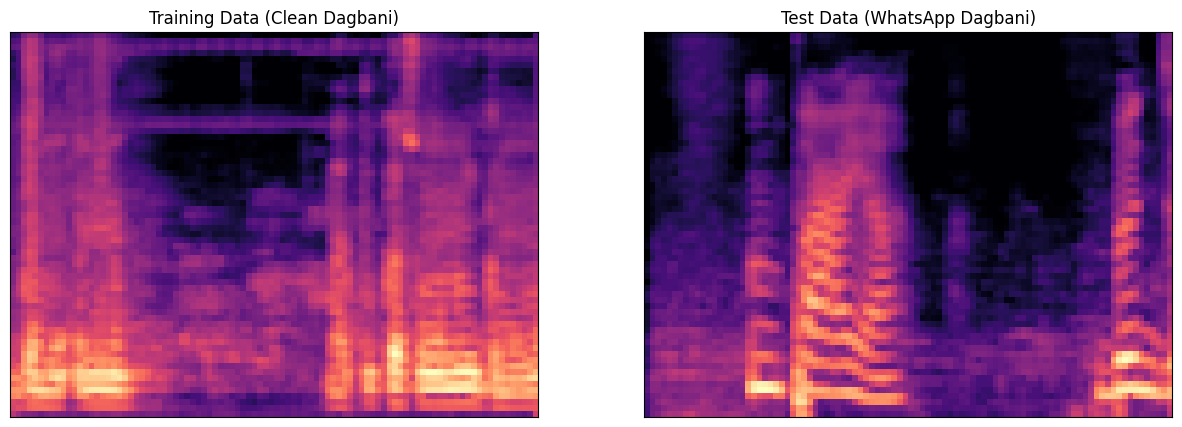

In [11]:
# Compare a 'perfect' Dagbani sample with your WhatsApp sample
import matplotlib.pyplot as plt

# 1. Get a clean Dagbani sample from your training data (X[0])
clean_dag = X[0]

# 2. Extract features from your WhatsApp file (we'll assume it's saved as 'test.mp4')
test_audio, _ = librosa.load("WhatsApp Audio 2026-03-17 at 1.14.34 AM.mp4", sr=16000)
test_dag = extract_features(test_audio)

# Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
librosa.display.specshow(clean_dag, ax=ax[0])
ax[0].set_title("Training Data (Clean Dagbani)")
librosa.display.specshow(test_dag, ax=ax[1])
ax[1].set_title("Test Data (WhatsApp Dagbani)")
plt.show()